In [22]:
# Image Classifier:


import numpy as np

# Colored Images - RGB (Red Green Blue) 3D (HEIGHT, WIDTH, 3 )
# GreySclae Images - 0 255 (Black White) 2D (HEIGHT , WIDTH)

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


import os

import cv2 


import tensorflow as tf


# Neural Networks - Layers 
# Tensors - multi-dimensional arrays (matrix)
# Layers - function 


from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential


# Convolutional Neural Networks: CNN 



# Conv2D: Convolution -  features extraction 
# edges, corners, shapes, textures

# filter/ kernel -> tiny matrix 3x3 - calculate weights 

# MaxPooling2D - compressor - downsampling
# reduce width/height,  
# Remove noise 

# Flatten converts 2d, 3d to 1d

# Dense: decision making : class score

# Dropout - Regularization - reduce overfitting - dropping out some neurons 

# Neurons - Input - multiply weights - sum - activation function - output 


import pickle






In [3]:
dataset_path = "/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

cats_path = os.path.join(dataset_path, "Cat")
dogs_path = os.path.join(dataset_path, "Dog")

In [5]:
IMG_SIZE = 128

data = []
labels = []

# Cats

for file in os.listdir(cats_path)[: 3000]:
    try:
        img_path = os.path.join(cats_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(0)
    except: 
        pass
# Dogs
for file in os.listdir(cats_path)[: 3000]:
    try:
        img_path = os.path.join(dogs_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        data.append(img)
        labels.append(1)
    except: 
        pass   

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


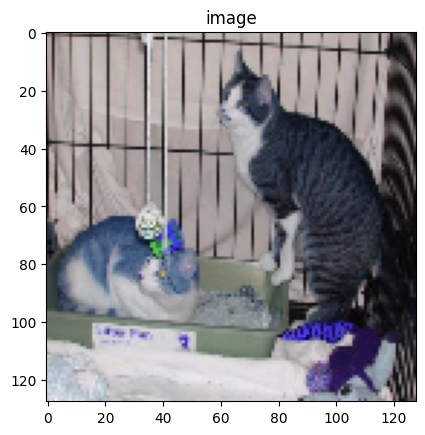

In [6]:
plt.imshow(data[0])
plt.title("image")
plt.show()

In [7]:
print(data[0].shape)

(128, 128, 3)


In [8]:
print(data[0])

[[[ 92  80  73]
  [ 89  95  89]
  [ 30  27  24]
  ...
  [ 73  68  65]
  [ 35  31  28]
  [ 27  21  16]]

 [[137 107 104]
  [143 131 127]
  [ 53  32  32]
  ...
  [104  99  96]
  [ 56  51  48]
  [ 25  20  11]]

 [[188 162 157]
  [175 167 163]
  [ 46  29  28]
  ...
  [121 117 114]
  [ 75  70  67]
  [ 30  25  15]]

 ...

 [[184 193 204]
  [195 203 213]
  [202 208 218]
  ...
  [126 123 123]
  [ 23  18  17]
  [147 138 139]]

 [[200 208 223]
  [214 221 233]
  [221 225 234]
  ...
  [105 102 101]
  [ 38  34  31]
  [121 108 111]]

 [[200 201 216]
  [214 216 229]
  [211 212 222]
  ...
  [ 84  77  76]
  [ 85  84  82]
  [ 94  80  86]]]


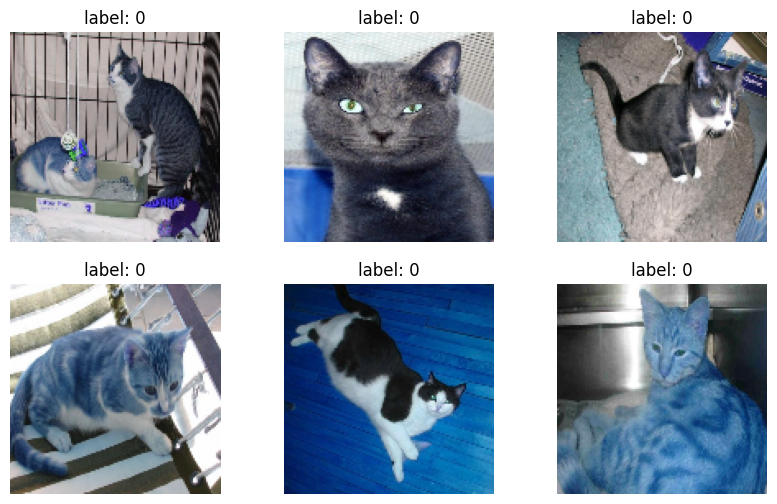

In [9]:
plt.figure(figsize = (10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(data[i])
    plt.title("label: " + str(labels[i]))
    plt.axis("off")

plt.show()

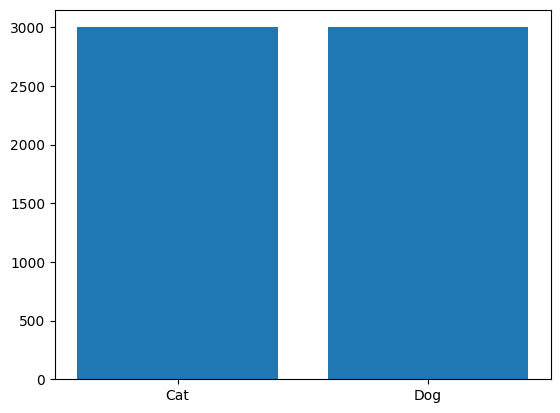

In [10]:
unique , counts = np.unique(labels, return_counts = True)

plt.bar(["Cat", "Dog"], counts)
plt.show()

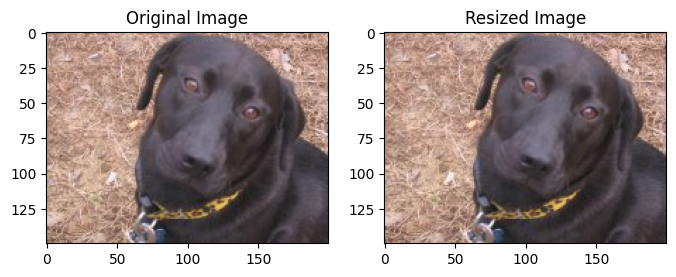

In [11]:
img = cv2.imread(img_path)

plt.figure(figsize = (8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")

img_resized = cv2.resize(img, (128,128))

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")


plt.show()


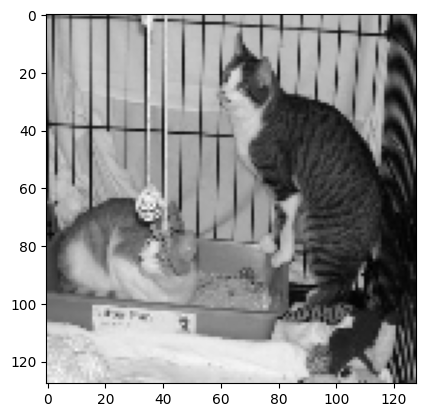

In [12]:
gray = cv2.cvtColor(data[0], cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap = "gray")
plt.show()

In [13]:
data = np.array(data)/255.0
labels = np.array(labels)

print("Data Shape: " , data.shape)
print("Labels shape", labels.shape)


Data Shape:  (6000, 128, 128, 3)
Labels shape (6000,)


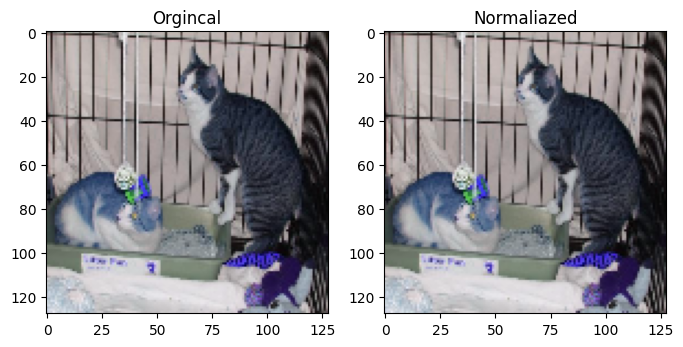

In [14]:
img = data[0] * 255
normalized_img = img/255.0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img.astype("uint8"))
plt.title("Orgincal")

plt.subplot(1,2,2)
plt.imshow(normalized_img)
plt.title("Normaliazed")

plt.show()



In [15]:
print("Before: ", img[50][50])
print("After: ", normalized_img[50][50])

Before:  [170. 160. 160.]
After:  [0.66666667 0.62745098 0.62745098]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size = 0.2, random_state = 42
)

In [17]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4800, 128, 128, 3)
(4800,)
(1200, 128, 128, 3)
(1200,)


In [18]:
model = Sequential()

# 128X128
model.add(Conv2D(32, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 64X64
model.add(Conv2D(64, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 32X32
model.add(Conv2D(128, (3,3),activation = "relu", input_shape= (128,128,3)))
model.add(MaxPooling2D(2,2))
# 16X16

model.add(Flatten())
model.add(Dense(128, activation= 'relu'))

model.add(Dropout(0.5))

model.add(Dense(1,activation = 'sigmoid'))





/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-12 17:46:19.663535: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
model.compile(
    optimizer = "adam",
    loss  = "binary_crossentropy",
    metrics = ['accuracy']
)

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test,y_test),
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 79s 514ms/step - accuracy: 0.5075 - loss: 0.7294 - val_accuracy: 0.5100 - val_loss: 0.6890
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 75s 502ms/step - accuracy: 0.5738 - loss: 0.6789 - val_accuracy: 0.6442 - val_loss: 0.6448
Epoch 3/10
 44/150 ━━━━━━━━━━━━━━━━━━━━ 49s 468ms/step - accuracy: 0.6021 - loss: 0.6520

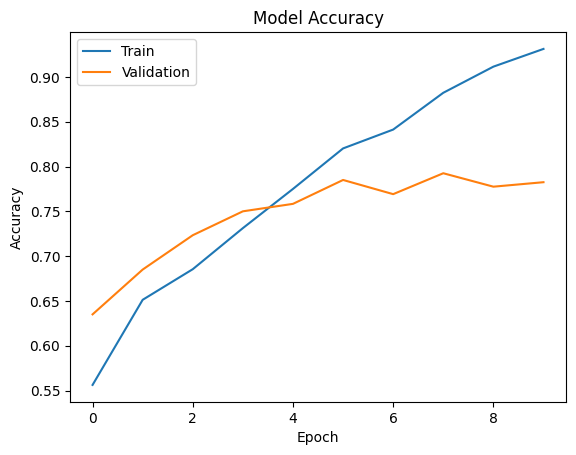

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])
plt.show()

In [55]:
model.save("animal_classifier.h5")

In [ ]:
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from PIL import Image


model = load_model("animal_classifier.h5")


IMG_SIZE = 128


def predict_image(image):
    img = np.array(image)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = img / 255.0

    img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img)

    if prediction[0][0] > 0.5:
        return "Dog 🐶"
    else:
        return "Cat 🐱"
    




st.title("Animal Image Classifier")

st.write("Upload an image of a cat or a dog")

uploaded_file = uploaded_file = st.file_uploader("Choose an image...", type=["jpg","jpeg","png"])


if uploaded_file is not None:

    image = Image.open(uploaded_file)

    st.image(image, caption = "Uploaded Image", use_column_width= True)

    st.write("Predicting...")

    result = predict_image(image)

    st.success(f"Prediction: {result}")











